# Detección de Objetos en Imágenes con YOLO

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** IA & Big Data · Visión Artificial · Detección de objetos (YOLOv8)

---

### Objetivo

Usar **YOLOv8** preentrenado (80 clases de COCO) para detectar y localizar automáticamente los objetos que aparecen en fotografías de interiorismo, sin entrenar ningún modelo propio.

### Contexto de negocio

**El cliente:** una tienda de mobiliario y decoración con un catálogo de fotos de ambientes (salones, dormitorios) tipo showroom.

**El problema:** el catálogo de fotos crece más rápido que la capacidad de etiquetarlo a mano. Sin etiquetas por producto, esas imágenes no son buscables ("quiero un salón con sofá verde") ni reutilizables para recomendaciones visuales.

**La pregunta:** ¿puede un modelo de detección de objetos genérico (no entrenado para mobiliario específicamente) identificar automáticamente qué hay en cada foto, y con qué fiabilidad, sin anotar una sola imagen a mano?

## 1. Setup: librerías y modelo

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

modelo = YOLO("yolov8n.pt")  # variantes disponibles: yolov8s/m/l/x.pt (más precisión, más lento)

print(f"Clases que reconoce el modelo: {len(modelo.names)}")
print(list(modelo.names.values()))

Clases que reconoce el modelo: 80
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


YOLOv8n ("nano") es la versión más ligera de la familia YOLOv8, entrenada sobre el dataset **COCO** (80 clases de objetos cotidianos: personas, muebles, electrodomésticos, vehículos...). No sabe nada de mobiliario de una marca en concreto — solo reconoce categorías genéricas como `couch`, `chair`, `potted plant` o `clock`. Es exactamente lo que necesitamos para una primera pasada automática de etiquetado.

## 2. Función de detección

In [2]:
def detectar_objetos(ruta_imagen, umbral_confianza=0.5):
    """Ejecuta YOLO sobre una imagen y devuelve el resultado (cajas, clases, confianza)."""
    resultados = modelo(ruta_imagen, conf=umbral_confianza, verbose=False)
    return resultados[0]


def mostrar_resultados(resultado, titulo="Objetos detectados"):
    imagen_anotada = resultado.plot()
    imagen_anotada_rgb = cv2.cvtColor(imagen_anotada, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(imagen_anotada_rgb)
    plt.axis("off")
    plt.title(titulo)
    plt.show()


def resumen_detecciones(resultado):
    for caja in resultado.boxes:
        clase = modelo.names[int(caja.cls[0])]
        confianza = float(caja.conf[0])
        print(f"  {clase:<15} confianza={confianza:.2f}")

## 3. Caso 1 — Salón

Objetos detectados: 10
  bowl            confianza=0.89
  chair           confianza=0.88
  potted plant    confianza=0.81
  vase            confianza=0.79
  chair           confianza=0.73
  clock           confianza=0.73
  vase            confianza=0.72
  vase            confianza=0.69
  couch           confianza=0.57
  vase            confianza=0.52


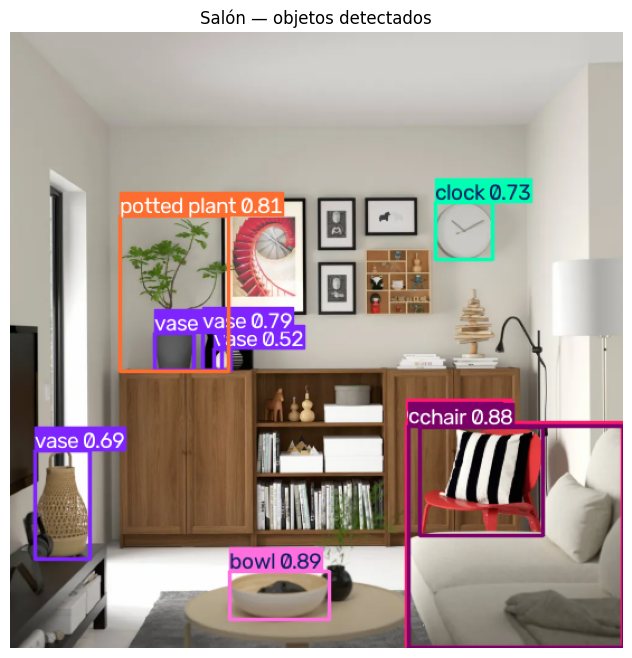

In [3]:
resultado_salon = detectar_objetos("salon.png", umbral_confianza=0.5)

print(f"Objetos detectados: {len(resultado_salon.boxes)}")
resumen_detecciones(resultado_salon)

mostrar_resultados(resultado_salon, "Salón — objetos detectados")

El modelo encuentra **10 objetos** con confianza ≥ 0.5: identifica correctamente el `couch` (0.57), la `chair` en dos ocasiones (0.88 y 0.73), el `clock` de pared (0.73) y hasta **4 `vase`** distintos sobre las estanterías — con confianzas que van de 0.52 a 0.79. La detección más segura de todas es un `bowl` (0.89), el cuenco decorativo sobre la mesa de centro. Ningún objeto se confunde de categoría; el ruido está solo en cuántos jarrones separa (podría estar contando algún objeto decorativo como `vase` cuando en realidad es otra cosa).

## 4. Caso 2 — Dormitorio

Objetos detectados: 3
  bed             confianza=0.72
  potted plant    confianza=0.69
  couch           confianza=0.56


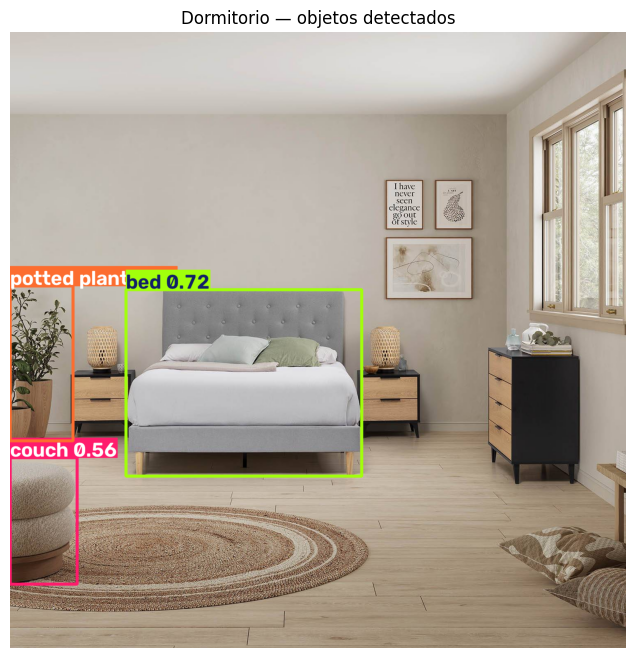

In [4]:
resultado_dormitorio = detectar_objetos("dormitorio.jpg", umbral_confianza=0.5)

print(f"Objetos detectados: {len(resultado_dormitorio.boxes)}")
resumen_detecciones(resultado_dormitorio)

mostrar_resultados(resultado_dormitorio, "Dormitorio — objetos detectados")

Aquí el modelo solo encuentra **3 objetos**: la `bed` (0.72), una `potted plant` (0.69) — y un `couch` (0.56) que en realidad es el puf/otomana en primer plano, no un sofá. Es un **falso positivo de categoría, no de localización**: la caja está bien situada sobre un objeto real, pero COCO no tiene una clase "puf" y el modelo elige la más parecida que conoce. La mesita de noche, la cómoda y las lámparas — todos ausentes de COCO como clases — quedan sin detectar, no porque el modelo falle, sino porque nunca se le enseñó a reconocerlos.

## 5. Conclusión

> **El hallazgo:** un modelo de detección genérico, sin entrenar para mobiliario, ya aporta valor real de etiquetado automático (sofás, sillas, plantas, relojes con confianza > 0.5), pero su cobertura depende por completo de las 80 clases de COCO — todo lo que no sea una categoría cotidiana (pufs, mesitas, lámparas de diseño) queda invisible o se etiqueta como el objeto más parecido que sí conoce.

**Recomendaciones:**

1. **Uso inmediato, bajo riesgo:** usar YOLOv8 base para un primer etiquetado automático masivo del catálogo (sofás, sillas, plantas, relojes) — reduce el trabajo manual sin necesidad de anotar ni entrenar nada.
2. **Para cobertura completa del catálogo:** haría falta un fine-tuning con fotos propias etiquetadas (pufs, mesitas auxiliares, lámparas), o combinar YOLO con un modelo de clasificación de producto más específico para las cajas que detecta pero no sabe nombrar bien.
3. **Límite honesto:** la confianza del modelo (0.5-0.9) no distingue entre "detecté el objeto correcto" y "detecté *un* objeto pero con la etiqueta equivocada" (el caso del puf) — cualquier pipeline de etiquetado automático necesita una revisión humana ligera antes de publicar, no solo un umbral de confianza.